In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sns


In [2]:
data=pd.read_csv('Student_Performance.csv')

In [3]:
data.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [4]:
data['Extracurricular Activities']=data['Extracurricular Activities'].replace({'Yes':1,'No':0})

C:\Users\AdminIT\AppData\Local\Temp\ipykernel_42672\918049896.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Extracurricular Activities']=data['Extracurricular Activities'].replace({'Yes':1,'No':0})


In [5]:
x=data[['Hours Studied','Previous Scores','Extracurricular Activities','Sleep Hours','Sample Question Papers Practiced']]
y=data[['Performance Index']]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=32)

In [8]:
from sklearn.linear_model import LinearRegression
performance_predictor=LinearRegression()

In [9]:
performance_predictor.fit(x_train,y_train)

LinearRegression()

In [10]:
y_train_predictor=performance_predictor.predict(x_train)

In [13]:
from math import sqrt

In [14]:
from sklearn.metrics import mean_squared_error,r2_score

In [15]:
sqrt(mean_squared_error(y_train,y_train_predictor))

2.0343219674106883

In [16]:
r2_score(y_train,y_train_predictor)

0.9888073733078652

In [17]:
y_test_predictor=performance_predictor.predict(x_test)

In [18]:
sqrt(mean_squared_error(y_test,y_test_predictor))

2.0509535012827804

In [19]:
r2_score(y_test,y_test_predictor)

0.9885198444421318

In [20]:
def performance(hours_studied, previous_scores, extracurricular_activities, sleep_hours, sample_question):
    return performance_predictor.predict([[hours_studied, previous_scores, extracurricular_activities, sleep_hours, sample_question]])

In [21]:
hours = float(input('Enter your study hours: '))
prev = float(input('Enter your previous scores: '))
extra = float(input('Enter your extra curricular activities (1 for Yes, 0 for No): '))
sleep = float(input('Enter your sleep hours here: '))
sample = float(input('Enter your sample question papers practiced: '))

prediction = performance(hours, prev, extra, sleep, sample)

print('Your predicted performance index is:', prediction[0])

Enter your study hours:  4
Enter your previous scores:  98
Enter your extra curricular activities (1 for Yes, 0 for No):  5
Enter your sleep hours here:  7
Enter your sample question papers practiced:  5


Your predicted performance index is: [84.32530185]


C:\Users\AdminIT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


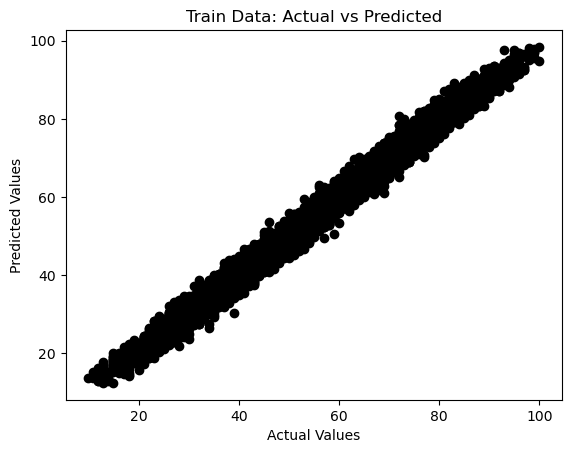

In [22]:
import matplotlib.pyplot as plt
plt.scatter(y_train, y_train_predictor, color='black')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Train Data: Actual vs Predicted')
plt.show()